In [1]:
import os 
data_raw_path = 'Formula-1/data/data_raw'
dirs = [x for x in os.listdir(data_raw_path) if not x.startswith('.')]

for dirc in dirs:
    dir_raw_path = data_raw_path + '/' + dirc
    #os.filepaths


In [2]:
data_raw_path = 'Formula-1/data/data_raw'

file_paths = [dirpath+'/'+filename for dirpath, dirnames, filenames in os.walk(data_raw_path) for filename in filenames ]
#for dirpath, dirnames, filenames in os.walk(data_raw_path):
    #print(f"Current Folder: {dirpath}")
   ## print(f"Subdirectories: {dirnames}")
   # print(f"Files: {filenames}")
   # print("-" * 20)
print(file_paths)

['Formula-1/data/data_raw/2018/session_11_Q/laps.csv', 'Formula-1/data/data_raw/2018/session_11_Q/drivers.csv', 'Formula-1/data/data_raw/2018/session_11_Q/total_laps.csv', 'Formula-1/data/data_raw/2018/session_11_Q/track_status.csv', 'Formula-1/data/data_raw/2018/session_11_Q/race_control_messages.csv', 'Formula-1/data/data_raw/2018/session_11_Q/event.csv', 'Formula-1/data/data_raw/2018/session_11_Q/weather_data.csv', 'Formula-1/data/data_raw/2018/session_11_Q/session_status.csv', 'Formula-1/data/data_raw/2018/session_11_Q/results.csv', 'Formula-1/data/data_raw/2018/session_11_Q/session_info.csv', 'Formula-1/data/data_raw/2018/session_4_Q/laps.csv', 'Formula-1/data/data_raw/2018/session_4_Q/drivers.csv', 'Formula-1/data/data_raw/2018/session_4_Q/total_laps.csv', 'Formula-1/data/data_raw/2018/session_4_Q/track_status.csv', 'Formula-1/data/data_raw/2018/session_4_Q/race_control_messages.csv', 'Formula-1/data/data_raw/2018/session_4_Q/event.csv', 'Formula-1/data/data_raw/2018/session_4_Q/

In [3]:
from pyspark.sql.functions import input_file_name, regexp_extract, col
from pyspark.sql import SparkSession

spark = (SparkSession
         .builder
         .appName('SparkDBApp')
         .getOrCreate())

df = spark.read.csv(
    "Formula-1/data/data_raw/*/session_*/drivers.csv",
    header=True,
    inferSchema=True
)
drivers = df.withColumn(
    "session_number",
    regexp_extract(input_file_name(), r"session_(\d+)", 1).cast("int")
)

#drivers.show(50)
file_names = ['drivers', 
              #'event',
              'laps',
              'race_control_messages',
              'results',
              'session_info',
              'session_status',
              'track_status',
              'weather_data']
def load_files(file_name):
    df = spark.read.csv(
        f"Formula-1/data/data_raw/*/session_*/{file_name}.csv",
        header=True,
        inferSchema=True
    )

    file_path = input_file_name()
    df = (
        df
        .withColumn('source_file', file_path)
        .withColumn(
            'year',
            regexp_extract(col('source_file'), r'data_raw/(\d{4})/', 1).cast('int')
        )
        .withColumn(
            'session_number',
            regexp_extract(col('source_file'), r'session_(\d+)', 1).cast('int')
        )
        .withColumn('type_of_race',
                   regexp_extract(col('source_file'), r'session_\d+_(\S)', 1).cast('string')
                   )
        .drop('_c0')
    )

    return df

load_files('drivers').show(50)


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/24 15:52:08 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/06/24 15:52:11 WARN FileStreamSink: Assume no metadata directory. Error while looking for metadata directory in the path: Formula-1/data/data_raw/*/session_*/drivers.csv.
java.io.FileNotFoundException: File Formula-1/data/data_raw/*/session_*/drivers.csv does not exist
	at org.apache.hadoop.fs.RawLocalFileSystem.deprecatedGetFileStatus(RawLocalFileSystem.java:980)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileLinkStatusInternal(RawLocalFileSystem.java:1301)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileStatus(RawLocalFileSystem.java:970)
	at org.apache.hadoop.fs.FilterFileSystem.getFileStatus(FilterFileSystem.java:462)
	at or

+---+--------------------+----+--------------+------------+
|  0|         source_file|year|session_number|type_of_race|
+---+--------------------+----+--------------+------------+
| 63|file:///sfs/gpfs/...|2026|             1|           Q|
| 12|file:///sfs/gpfs/...|2026|             1|           Q|
|  6|file:///sfs/gpfs/...|2026|             1|           Q|
| 16|file:///sfs/gpfs/...|2026|             1|           Q|
| 81|file:///sfs/gpfs/...|2026|             1|           Q|
|  1|file:///sfs/gpfs/...|2026|             1|           Q|
| 44|file:///sfs/gpfs/...|2026|             1|           Q|
| 30|file:///sfs/gpfs/...|2026|             1|           Q|
| 41|file:///sfs/gpfs/...|2026|             1|           Q|
|  5|file:///sfs/gpfs/...|2026|             1|           Q|
| 27|file:///sfs/gpfs/...|2026|             1|           Q|
| 87|file:///sfs/gpfs/...|2026|             1|           Q|
| 31|file:///sfs/gpfs/...|2026|             1|           Q|
| 10|file:///sfs/gpfs/...|2026|         

In [7]:
#spark.sql("CREATE DATABASE learn_spark_db")
#spark.sql("USE learn_spark_db")
#spark.sql("CREATE TABLE managed_us_delay_flights_tbl (date STRING, delay INT,  distance INT, origin STRING, destination STRING)")
spark.sql('DROP database formula1')
spark.sql('CREATE database IF NOT EXISTS formula1')
spark.sql('USE formula1')

DataFrame[]

In [8]:
drivers = load_files("drivers")
laps = load_files("laps")
results = load_files("results")
session_info = load_files("session_info")
session_status = load_files("session_status")
track_status = load_files("track_status")
weather_data = load_files("weather_data")

26/06/24 15:53:28 WARN FileStreamSink: Assume no metadata directory. Error while looking for metadata directory in the path: Formula-1/data/data_raw/*/session_*/drivers.csv.
java.io.FileNotFoundException: File Formula-1/data/data_raw/*/session_*/drivers.csv does not exist
	at org.apache.hadoop.fs.RawLocalFileSystem.deprecatedGetFileStatus(RawLocalFileSystem.java:980)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileLinkStatusInternal(RawLocalFileSystem.java:1301)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileStatus(RawLocalFileSystem.java:970)
	at org.apache.hadoop.fs.FilterFileSystem.getFileStatus(FilterFileSystem.java:462)
	at org.apache.spark.sql.execution.streaming.sinks.FileStreamSink$.hasMetadata(FileStreamSink.scala:58)
	at org.apache.spark.sql.execution.datasources.DataSource.resolveRelation(DataSource.scala:384)
	at org.apache.spark.sql.catalyst.analysis.ResolveDataSource.org$apache$spark$sql$catalyst$analysis$ResolveDataSource$$loadV1BatchSource(ResolveDataSource.scala

In [9]:
drivers.write.mode("overwrite").saveAsTable("formula1.drivers")
laps.write.mode("overwrite").saveAsTable("formula1.laps")
results.write.mode("overwrite").saveAsTable("formula1.results")
session_info.write.mode("overwrite").saveAsTable("formula1.session_info")
session_status.write.mode("overwrite").saveAsTable("formula1.session_status")
track_status.write.mode("overwrite").saveAsTable("formula1.track_status")
weather_data.write.mode("overwrite").saveAsTable("formula1.weather_data")

26/06/24 15:57:51 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: 
 Schema: 0
Expected: 0 but found: 
CSV file: file:///sfs/gpfs/tardis/home/azd9vv/Formula-1/data/data_raw/2026/session_8_R/drivers.csv
26/06/24 15:57:52 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/06/24 15:57:52 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/06/24 15:57:52 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 76.00% for 10 writers
26/06/24 15:57:52 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 69.09% for 11 writers
26/06/24 15:57:52 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 63.33% for 12 wr

In [10]:
import pyspark.sql.functions as F
event_long.select('field').distinct().show()

NameError: name 'event_long' is not defined

In [11]:
spark.sql('SHOW TABLES').show()

+---------+--------------+-----------+
|namespace|     tableName|isTemporary|
+---------+--------------+-----------+
| formula1|       drivers|      false|
| formula1|          laps|      false|
| formula1|       results|      false|
| formula1|  session_info|      false|
| formula1|session_status|      false|
| formula1|  track_status|      false|
| formula1|  weather_data|      false|
+---------+--------------+-----------+



In [12]:
spark.sql('Select * From formula1.drivers').show()

+---+--------------------+----+--------------+------------+
|  0|         source_file|year|session_number|type_of_race|
+---+--------------------+----+--------------+------------+
| 44|file:///sfs/gpfs/...|2019|             8|           Q|
| 77|file:///sfs/gpfs/...|2019|             8|           Q|
| 16|file:///sfs/gpfs/...|2019|             8|           Q|
| 33|file:///sfs/gpfs/...|2019|             8|           Q|
|  4|file:///sfs/gpfs/...|2019|             8|           Q|
| 55|file:///sfs/gpfs/...|2019|             8|           Q|
|  5|file:///sfs/gpfs/...|2019|             8|           Q|
|  3|file:///sfs/gpfs/...|2019|             8|           Q|
| 10|file:///sfs/gpfs/...|2019|             8|           Q|
| 99|file:///sfs/gpfs/...|2019|             8|           Q|
| 23|file:///sfs/gpfs/...|2019|             8|           Q|
|  7|file:///sfs/gpfs/...|2019|             8|           Q|
| 27|file:///sfs/gpfs/...|2019|             8|           Q|
| 11|file:///sfs/gpfs/...|2019|         

In [13]:
drivers = spark.table('formula1.drivers')
drivers_fixed = drivers.withColumnRenamed("0", "driver_number")

drivers_fixed.write.mode("overwrite").saveAsTable("drivers_fixed")

spark.sql("DROP TABLE drivers")
spark.sql("ALTER TABLE drivers_fixed RENAME TO drivers")

26/06/24 15:58:07 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/06/24 15:58:07 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/06/24 15:58:07 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 76.00% for 10 writers
26/06/24 15:58:07 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 69.09% for 11 writers
26/06/24 15:58:07 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 63.33% for 12 writers
26/06/24 15:58:07 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 58.46% for 13 writers
26/06/24 15:58:07 WARN MemoryManager: Total allocation exceeds 95.

DataFrame[]

In [14]:
spark.sql('Select * From formula1.drivers').show()

+-------------+--------------------+----+--------------+------------+
|driver_number|         source_file|year|session_number|type_of_race|
+-------------+--------------------+----+--------------+------------+
|           63|file:///sfs/gpfs/...|2026|             7|           Q|
|           44|file:///sfs/gpfs/...|2026|             7|           Q|
|           12|file:///sfs/gpfs/...|2026|             7|           Q|
|            1|file:///sfs/gpfs/...|2026|             7|           Q|
|            3|file:///sfs/gpfs/...|2026|             7|           Q|
|            6|file:///sfs/gpfs/...|2026|             7|           Q|
|           81|file:///sfs/gpfs/...|2026|             7|           Q|
|           30|file:///sfs/gpfs/...|2026|             7|           Q|
|           27|file:///sfs/gpfs/...|2026|             7|           Q|
|           16|file:///sfs/gpfs/...|2026|             7|           Q|
|           41|file:///sfs/gpfs/...|2026|             7|           Q|
|            5|file:

In [15]:
laps = spark.table('laps')

In [16]:
#let's get the drivers in 2021's first race average speed per lap 

laps.select('Team','Driver')\
    .filter((col('year')==2021) & (col('session_number')==1) & col('LapTime').isNotNull())\
    .groupBy('Team','Driver')\
    .agg(F.mean('LapTime').alias('Average Lap Time'))

{"ts": "2026-06-24 15:58:11.886", "level": "ERROR", "logger": "DataFrameQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `LapTime` cannot be resolved. Did you mean one of the following? [`Team`, `Driver`]. SQLSTATE: 42703", "context": {"file": "jdk.internal.reflect.GeneratedMethodAccessor83.invoke(Unknown Source)", "line": "", "fragment": "col", "errorClass": "UNRESOLVED_COLUMN.WITH_SUGGESTION"}, "exception": {"class": "Py4JJavaError", "msg": "An error occurred while calling o576.agg.\n: org.apache.spark.sql.AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `LapTime` cannot be resolved. Did you mean one of the following? [`Team`, `Driver`]. SQLSTATE: 42703;\n'Aggregate [Team#715, Driver#694], [Team#715, Driver#694, 'avg('LapTime) AS Average Lap Time#729]\n+- Project [Team#715, Driver#694]\n   +- Filter (((year#725 = 2021) AND (session_number#726 = 1)) AND isnotnu

AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `LapTime` cannot be resolved. Did you mean one of the following? [`Team`, `Driver`]. SQLSTATE: 42703;
'Aggregate [Team#715, Driver#694], [Team#715, Driver#694, 'avg('LapTime) AS Average Lap Time#729]
+- Project [Team#715, Driver#694]
   +- Filter (((year#725 = 2021) AND (session_number#726 = 1)) AND isnotnull(LapTime#696))
      +- Project [Team#715, Driver#694, year#725, session_number#726, LapTime#696]
         +- SubqueryAlias spark_catalog.formula1.laps
            +- Relation spark_catalog.formula1.laps[Time#693,Driver#694,DriverNumber#695,LapTime#696,LapNumber#697,Stint#698,PitOutTime#699,PitInTime#700,Sector1Time#701,Sector2Time#702,Sector3Time#703,Sector1SessionTime#704,Sector2SessionTime#705,Sector3SessionTime#706,SpeedI1#707,SpeedI2#708,SpeedFL#709,SpeedST#710,IsPersonalBest#711,Compound#712,TyreLife#713,FreshTyre#714,Team#715,LapStartTime#716,LapStartDate#717,... 10 mor

In [17]:
laps.select('LapTime').show(5)

+--------------------+
|             LapTime|
+--------------------+
|0 days 00:01:22.8...|
|0 days 00:01:33.5...|
|0 days 00:01:31.4...|
|0 days 00:01:29.5...|
|0 days 00:01:32.3...|
+--------------------+
only showing top 5 rows


In [18]:
0 

0

In [19]:
from pyspark.sql.functions import col, regexp_extract, when, length

laps_clean_laptime = laps\
    .withColumn('laptime_days', 
                when(
                    length(regexp_extract(col("LapTime"), r"(\d+) days", 1)) > 0,
                    regexp_extract(col('LapTime'), r'(\d+) days', 1).cast('int')
                )
               )\
    .withColumn('laptime_hours',
                when(
                    length(regexp_extract(col("LapTime"), r'days (\d{2}):', 1)) > 0,
                    regexp_extract(col('LapTime'), r'days (\d{2}):', 1).cast('int')
                )
                )\
    .withColumn('laptime_minutes',
                when(
                    length(regexp_extract(col('LapTime'), r'days \d{2}:(\d{2}):', 1)) > 0,
                    regexp_extract(col('LapTime'), r'days \d{2}:(\d{2}):', 1).cast('int')
                )
                )\
    .withColumn('laptime_seconds',
                when(
                    length(regexp_extract(col('LapTime'), r'days \d{2}:\d{2}:(\d{2}.\d+)', 1)) > 0,
                    regexp_extract(col('LapTime'), r'days \d{2}:\d{2}:(\d{2}.\d+)', 1).cast('double')
                )
                )\
    .withColumn('total_laptime_secs',
                col('laptime_days')*60*3+col('laptime_hours')*60*2+col('laptime_minutes')*60+col('laptime_seconds'))\
    .drop('laptime_hours', 'laptime_minutes', 'laptime_seconds')
laps_clean_laptime.select('total_laptime_secs').show(5)

+------------------+
|total_laptime_secs|
+------------------+
| 82.82300000000001|
|            93.553|
| 91.40899999999999|
|            89.513|
|            92.311|
+------------------+
only showing top 5 rows


In [20]:
spark.sql('USE formula1')

DataFrame[]

In [21]:
laps_clean_laptime.write.mode("overwrite").saveAsTable("laps_time_fixed2")

spark.sql('DROP TABLE laps')
spark.sql('ALTER TABLE laps_time_fixed2 RENAME TO laps')

26/06/24 15:58:17 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/06/24 15:58:17 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/06/24 15:58:17 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 76.00% for 10 writers
26/06/24 15:58:17 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 69.09% for 11 writers
26/06/24 15:58:17 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 63.33% for 12 writers
26/06/24 15:58:17 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 58.46% for 13 writers
26/06/24 15:58:17 WARN MemoryManager: Total allocation exceeds 95.

DataFrame[]

In [22]:
laps = spark.sql('SELECT * from formula1.laps')

In [23]:
laps.printSchema()

root
 |-- Time: string (nullable = true)
 |-- Driver: string (nullable = true)
 |-- DriverNumber: integer (nullable = true)
 |-- LapTime: string (nullable = true)
 |-- LapNumber: double (nullable = true)
 |-- Stint: double (nullable = true)
 |-- PitOutTime: string (nullable = true)
 |-- PitInTime: string (nullable = true)
 |-- Sector1Time: string (nullable = true)
 |-- Sector2Time: string (nullable = true)
 |-- Sector3Time: string (nullable = true)
 |-- Sector1SessionTime: string (nullable = true)
 |-- Sector2SessionTime: string (nullable = true)
 |-- Sector3SessionTime: string (nullable = true)
 |-- SpeedI1: double (nullable = true)
 |-- SpeedI2: double (nullable = true)
 |-- SpeedFL: double (nullable = true)
 |-- SpeedST: double (nullable = true)
 |-- IsPersonalBest: boolean (nullable = true)
 |-- Compound: string (nullable = true)
 |-- TyreLife: double (nullable = true)
 |-- FreshTyre: boolean (nullable = true)
 |-- Team: string (nullable = true)
 |-- LapStartTime: string (nullable 

In [24]:
import pyspark.sql.functions as F
some_laps = laps.filter((col('year')==2021) &(col('session_number')==1) & (col('total_laptime_secs').isNotNull())).groupBy('Team', 'Driver', 'DriverNumber').agg(F.mean('total_laptime_secs').alias('Average Lap Time'))
some_laps.show()


+-----------------+------+------------+------------------+
|             Team|Driver|DriverNumber|  Average Lap Time|
+-----------------+------+------------+------------------+
|Alfa Romeo Racing|   GIO|          99|100.73774603174607|
|       AlphaTauri|   GAS|          10|100.35204999999999|
|         Mercedes|   BOT|          77|  99.3798181818182|
|           Alpine|   OCO|          31|100.93567796610171|
|          McLaren|   NOR|           4| 99.27007575757577|
|     Haas F1 Team|   MSC|          47|101.89305084745763|
|  Red Bull Racing|   VER|          33|  98.2530923076923|
|         Williams|   RUS|          63|101.36659677419355|
|         Williams|   LAT|           6|102.77485714285714|
|          McLaren|   RIC|           3| 99.54356060606062|
|          Ferrari|   LEC|          16|      99.308265625|
|         Mercedes|   HAM|          44| 98.04661194029853|
|          Ferrari|   SAI|          55|100.09658461538464|
|     Aston Martin|   VET|           5|101.2674745762711

In [25]:
laps.printSchema()
res = spark.sql('Select * from formula1.results')
res.show(10)

root
 |-- Time: string (nullable = true)
 |-- Driver: string (nullable = true)
 |-- DriverNumber: integer (nullable = true)
 |-- LapTime: string (nullable = true)
 |-- LapNumber: double (nullable = true)
 |-- Stint: double (nullable = true)
 |-- PitOutTime: string (nullable = true)
 |-- PitInTime: string (nullable = true)
 |-- Sector1Time: string (nullable = true)
 |-- Sector2Time: string (nullable = true)
 |-- Sector3Time: string (nullable = true)
 |-- Sector1SessionTime: string (nullable = true)
 |-- Sector2SessionTime: string (nullable = true)
 |-- Sector3SessionTime: string (nullable = true)
 |-- SpeedI1: double (nullable = true)
 |-- SpeedI2: double (nullable = true)
 |-- SpeedFL: double (nullable = true)
 |-- SpeedST: double (nullable = true)
 |-- IsPersonalBest: boolean (nullable = true)
 |-- Compound: string (nullable = true)
 |-- TyreLife: double (nullable = true)
 |-- FreshTyre: boolean (nullable = true)
 |-- Team: string (nullable = true)
 |-- LapStartTime: string (nullable 

In [26]:
res.printSchema()

root
 |-- DriverNumber: integer (nullable = true)
 |-- BroadcastName: string (nullable = true)
 |-- Abbreviation: string (nullable = true)
 |-- DriverId: string (nullable = true)
 |-- TeamName: string (nullable = true)
 |-- TeamColor: string (nullable = true)
 |-- TeamId: string (nullable = true)
 |-- FirstName: string (nullable = true)
 |-- LastName: string (nullable = true)
 |-- FullName: string (nullable = true)
 |-- HeadshotUrl: string (nullable = true)
 |-- CountryCode: string (nullable = true)
 |-- Position: double (nullable = true)
 |-- ClassifiedPosition: string (nullable = true)
 |-- GridPosition: double (nullable = true)
 |-- Q1: string (nullable = true)
 |-- Q2: string (nullable = true)
 |-- Q3: string (nullable = true)
 |-- Time: string (nullable = true)
 |-- Status: string (nullable = true)
 |-- Points: double (nullable = true)
 |-- Laps: double (nullable = true)
 |-- source_file: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- session_number: integer (n

In [27]:
some_res = res.filter((col('session_number')==1) & (col('year')==2021) & (col('Points').isNotNull())& (col('type_of_race')=='R')).select('TeamName', 'DriverNumber', 'Points').orderBy('Points')#.show(30)

In [28]:
join_res = some_res.join(some_laps, how='left', on='DriverNumber')
join_res.show(20)

+------------+-----------------+------+-----------------+------+------------------+
|DriverNumber|         TeamName|Points|             Team|Driver|  Average Lap Time|
+------------+-----------------+------+-----------------+------+------------------+
|          44|         Mercedes|  25.0|         Mercedes|   HAM| 98.04661194029853|
|          33|  Red Bull Racing|  18.0|  Red Bull Racing|   VER|  98.2530923076923|
|          77|         Mercedes|  16.0|         Mercedes|   BOT|  99.3798181818182|
|           4|          McLaren|  12.0|          McLaren|   NOR| 99.27007575757577|
|          11|  Red Bull Racing|  10.0|  Red Bull Racing|   PER|100.40133333333334|
|          16|          Ferrari|   8.0|          Ferrari|   LEC|      99.308265625|
|           3|          McLaren|   6.0|          McLaren|   RIC| 99.54356060606062|
|          55|          Ferrari|   4.0|          Ferrari|   SAI|100.09658461538464|
|          22|       AlphaTauri|   2.0|       AlphaTauri|   TSU|100.74309677

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

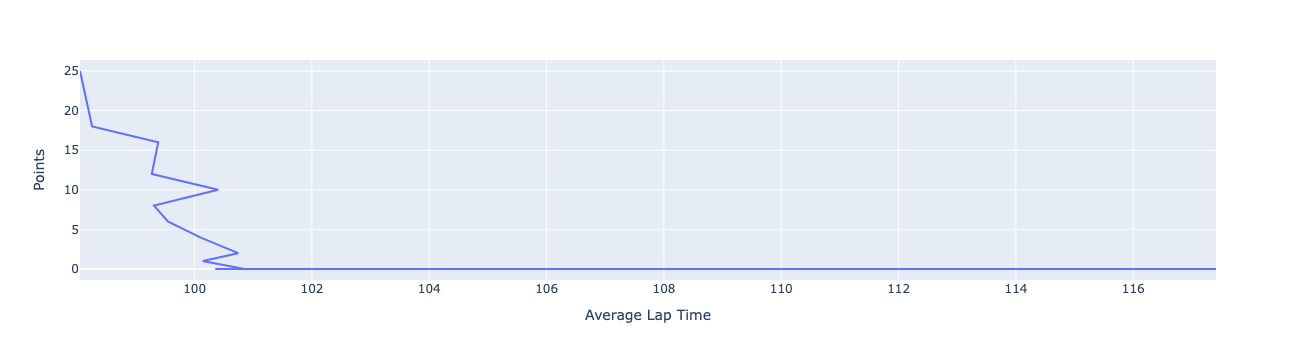

In [29]:
join_res.plot(y='Points', x='Average Lap Time')

In [39]:
# lets get the average lap position

some_pos = laps.filter((col('session_number')==1) & (col('year')==2021)).groupby('DriverNumber', 'Team').agg(F.mean('Position').alias('Average Position'))#.select('DriverNumber', 'Team', 'Position
some_pos.show(20)

+------------+-----------------+------------------+
|DriverNumber|             Team|  Average Position|
+------------+-----------------+------------------+
|          16|          Ferrari| 5.428571428571429|
|          33|  Red Bull Racing|1.4821428571428572|
|          44|         Mercedes|             1.625|
|          11|  Red Bull Racing| 7.928571428571429|
|          18|     Aston Martin|             8.875|
|          14|           Alpine|          10.46875|
|           7|Alfa Romeo Racing|11.017857142857142|
|          55|          Ferrari| 8.232142857142858|
|           4|          McLaren| 4.678571428571429|
|          22|       AlphaTauri|11.553571428571429|
|          31|           Alpine|12.927272727272728|
|          10|       AlphaTauri| 16.71153846153846|
|           6|         Williams|16.784313725490197|
|           3|          McLaren| 6.732142857142857|
|          63|         Williams|14.727272727272727|
|           9|     Haas F1 Team|              NULL|
|          9

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

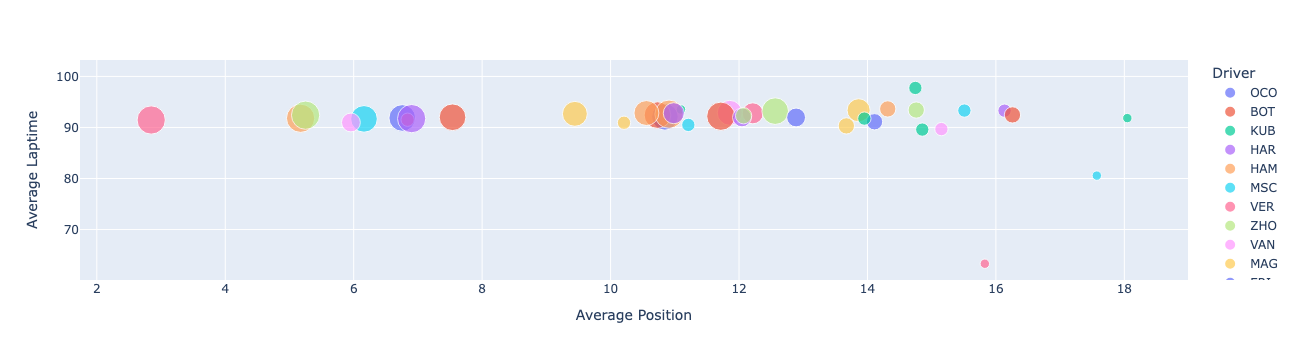

In [55]:
laps.groupby('Driver').agg(F.mean('Position').alias('Average Position'), F.mean('total_laptime_secs').alias('Average Laptime'),F.countDistinct("year").alias("Years Raced")).plot.scatter(x='Average Position', y='Average Laptime',color='Driver',size='Years Raced')#.show()

Defaulting to user installation because normal site-packages is not writeable
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached referencing-0.37.0-py3-none-any.whl.metadata (2.8 kB)
Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl (18 kB)
Using cached referencing-0.37.0-py3-none-any.whl (26 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━ 5/7 [jsonschema]  WARNING: The script jsonschema is installed in '/home/azd9vv/.local/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━ 6/7 [nbformat]  WARNING: The script jupyter-trust is installed in '/home/azd9vv/.local/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [nbformat]
